Saving Day14_Food_Delivery_Visualization_Dataset.csv to Day14_Food_Delivery_Visualization_Dataset.csv
Dataset loaded successfully.
Detected columns:
Date: date
Orders: orders
Revenue: revenue
City: city
Cuisine: cuisine
Marketing Spend: marketing_spend
Delivery Time: avg_delivery_minutes
Customer Rating: customer_rating
Weather: weather
Order Channel: order_channel


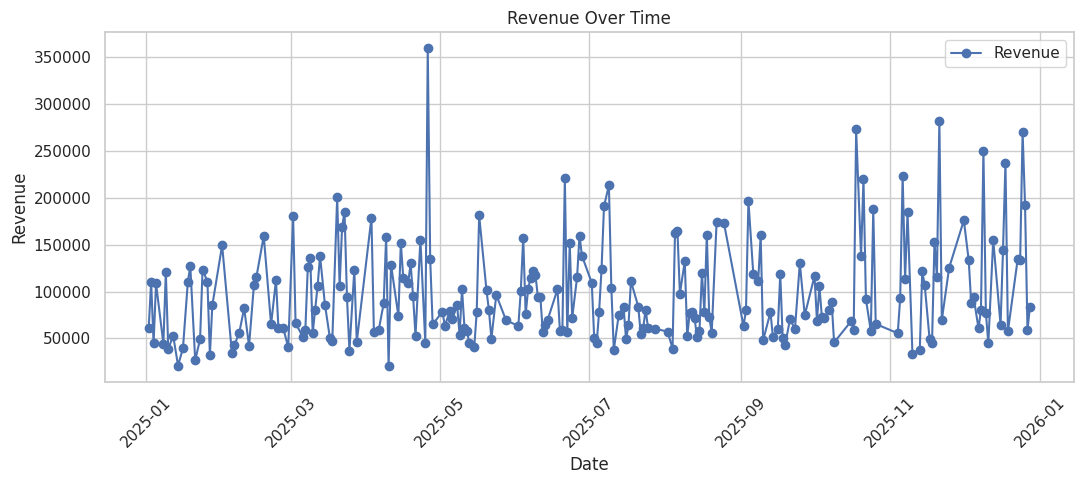

Interpretation: The line plot shows changes in revenue over time. Increasing values indicate stronger revenue performance, while decreasing values indicate weaker performance.


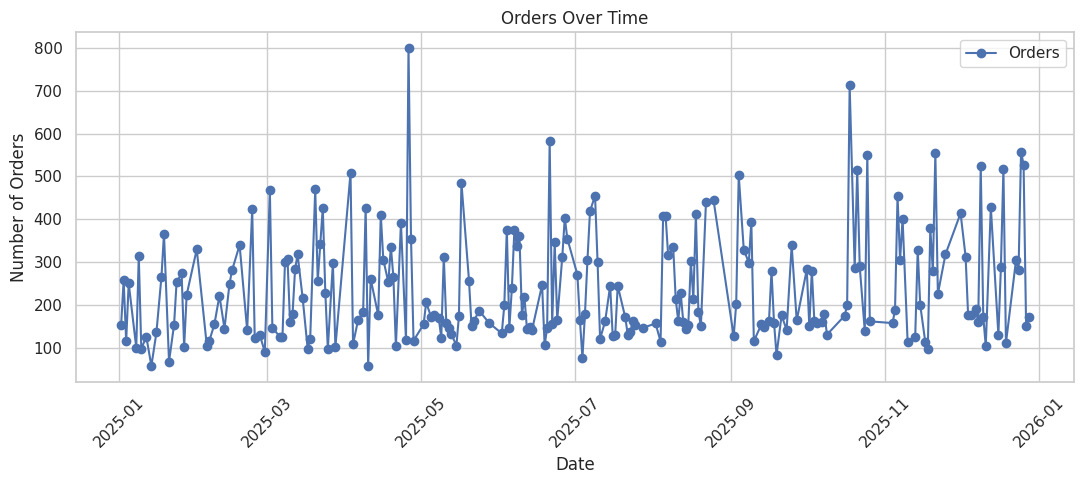

Interpretation: The line plot shows how order volume changes over time and highlights periods of higher and lower customer demand.


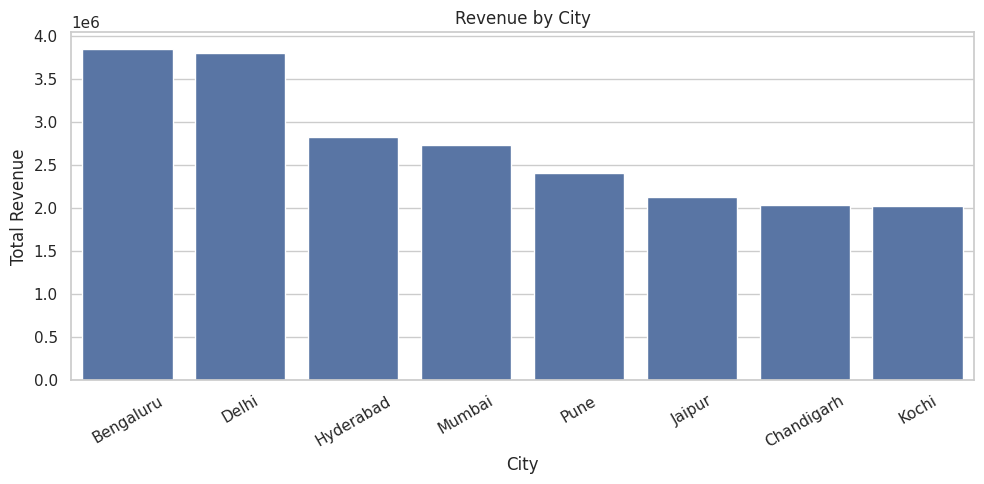

Interpretation: The bar chart compares revenue across cities and identifies locations with stronger business performance.


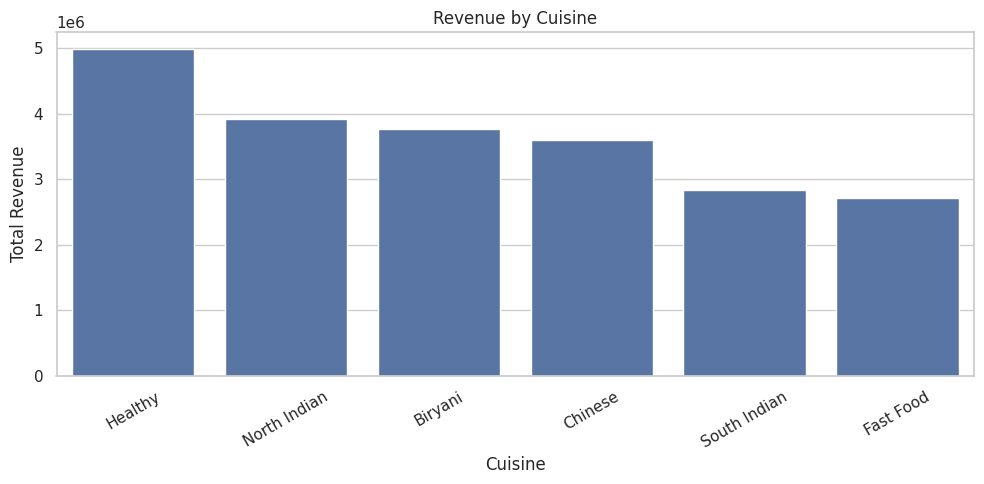

Interpretation: The bar chart compares revenue across cuisines and helps identify the most successful food categories.


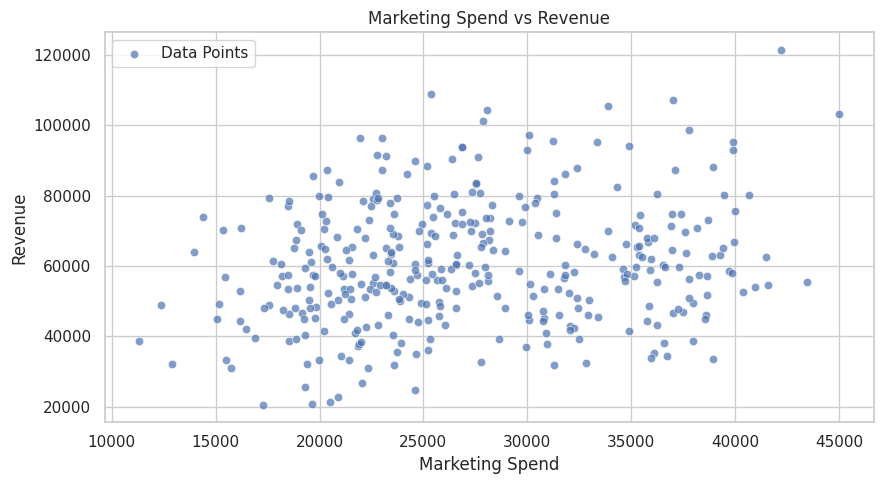

Interpretation: The scatter plot investigates the relationship between marketing spend and revenue. The correlation coefficient is 0.20.


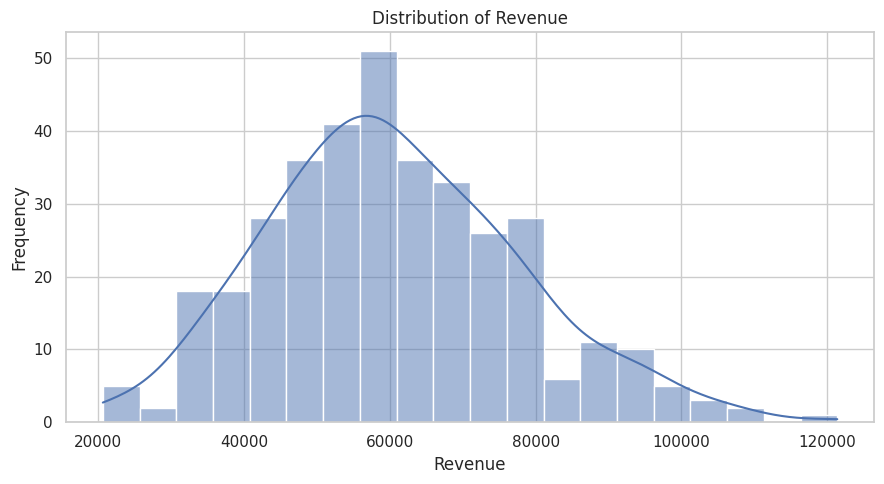

Interpretation: The histogram shows the distribution of revenue values and identifies the most common revenue ranges.


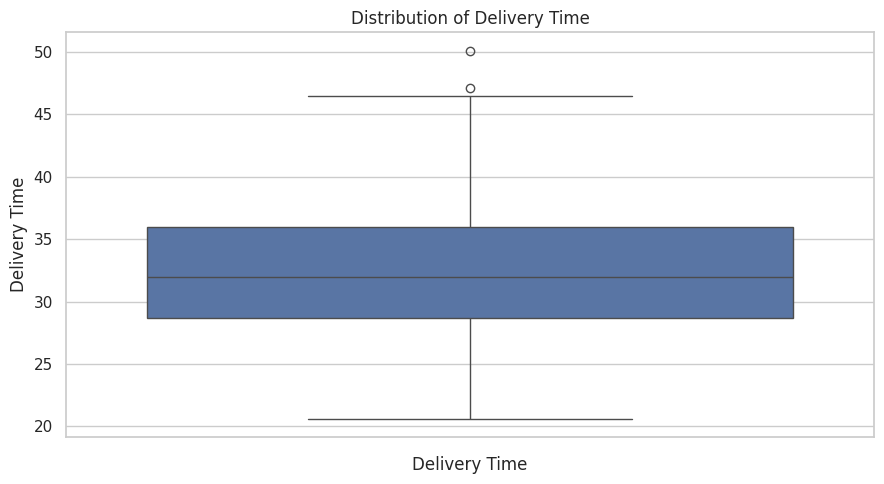

Interpretation: The box plot shows the central tendency and variation of delivery times and highlights possible extreme values.


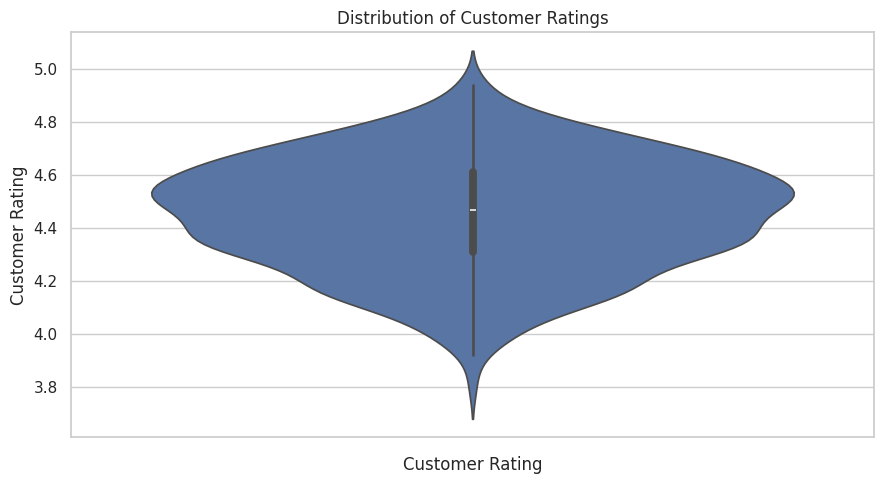

Interpretation: The violin plot shows the distribution and density of customer ratings and highlights the most common rating ranges.


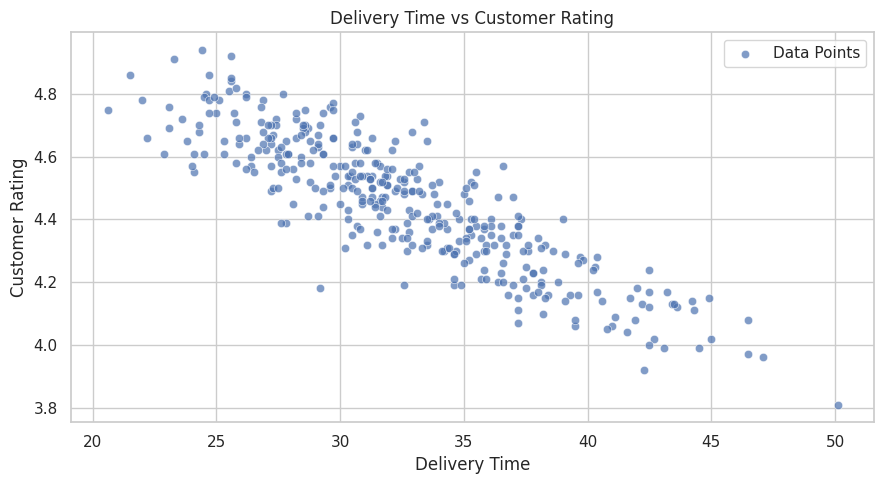

Interpretation: The scatter plot examines the relationship between delivery time and customer ratings. The correlation coefficient is -0.88.


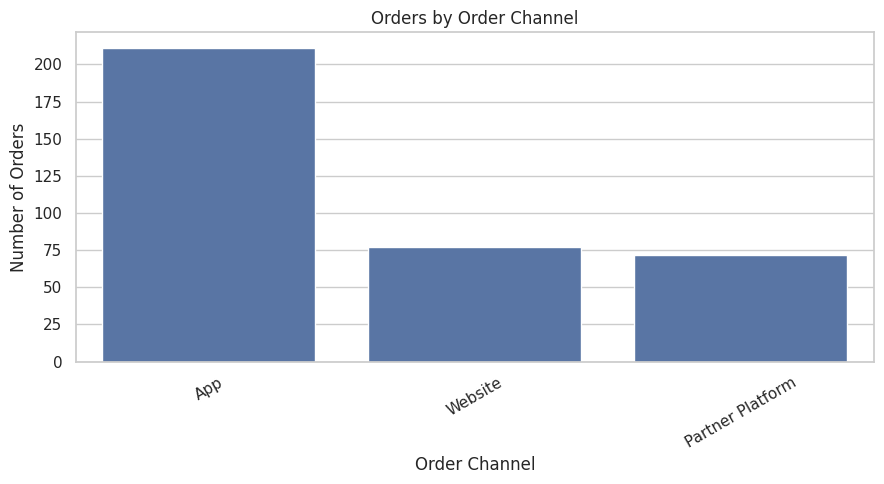

Interpretation: The count plot compares order volumes across different order channels and identifies the most frequently used channel.


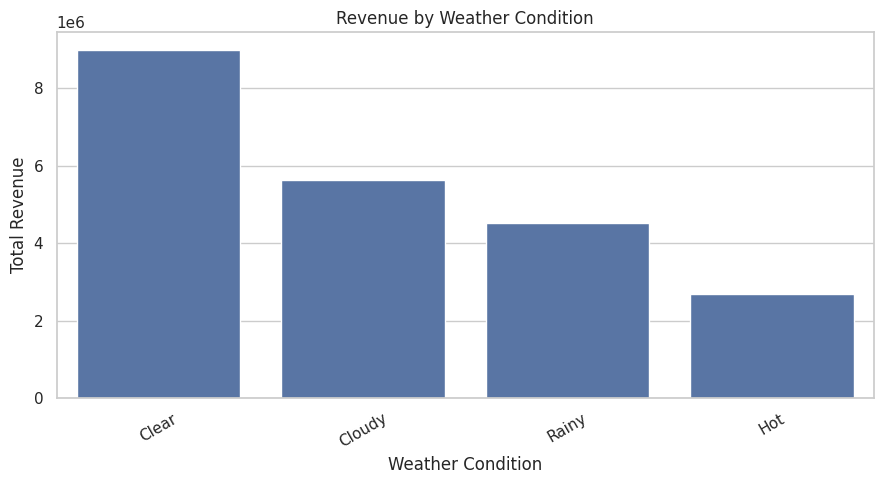

Interpretation: The bar chart compares revenue under different weather conditions and helps investigate whether weather is associated with differences in performance.


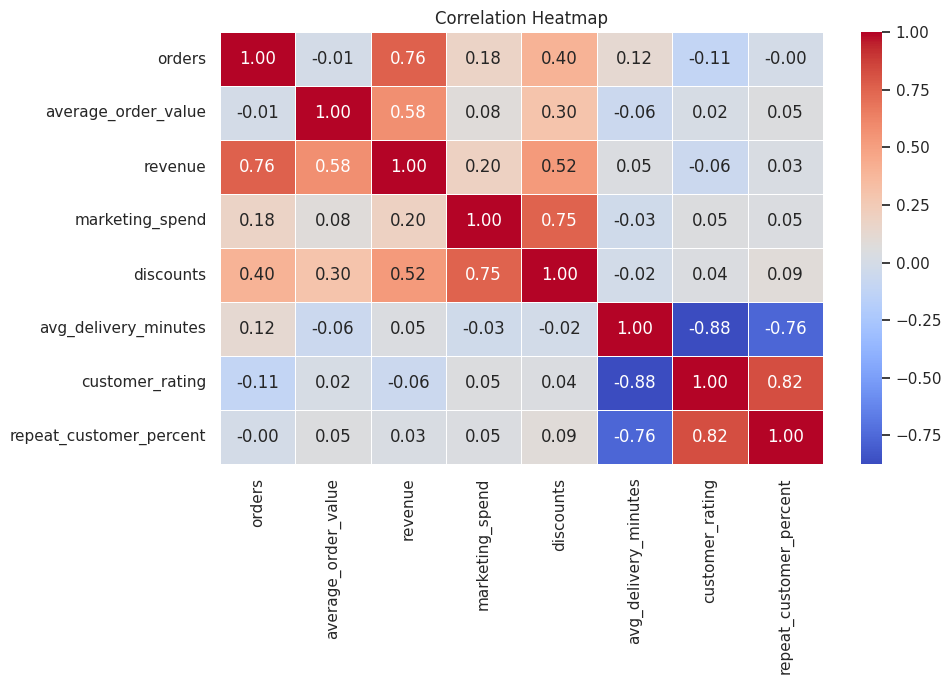

Interpretation: The correlation heatmap summarizes relationships among numerical variables. Positive values indicate positive relationships, negative values indicate negative relationships, and values near zero indicate weak relationships.

SUMMARY OF IMPORTANT FINDINGS
Highest Revenue City: Bengaluru
Highest Revenue Cuisine: Healthy
Marketing Spend vs Revenue Correlation: 0.2
Delivery Time vs Customer Rating Correlation: -0.88
Most Used Order Channel: App
Highest Revenue Weather Condition: Clear

Conclusion:
The visualization portfolio identifies important patterns in food delivery orders and revenue over time, differences between cities and cuisines, the relationship between marketing spend and revenue, delivery time and customer ratings, and the effect of weather and order channels on business performance. These visualizations provide meaningful insights that can support data-driven business decisions.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

uploaded = files.upload()
file_name = list(uploaded.keys())[0]

if file_name.lower().endswith(".csv"):
    df = pd.read_csv(file_name)
else:
    df = pd.read_excel(file_name)

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

def find_col(names):
    for name in names:
        if name in df.columns:
            return name
    for col in df.columns:
        for name in names:
            if name in col:
                return col
    return None

date_col = find_col(["date", "order_date", "orderdate"])
orders_col = find_col(["orders", "order_count", "number_of_orders", "total_orders"])
revenue_col = find_col(["revenue", "sales", "total_revenue", "sales_amount"])
city_col = find_col(["city"])
cuisine_col = find_col(["cuisine", "food_type", "food_category"])
marketing_col = find_col(["marketing_spend", "marketing", "advertising_spend", "ad_spend"])
delivery_col = find_col(["delivery_time", "delivery_minutes", "delivery_duration"])
rating_col = find_col(["customer_rating", "rating", "customer_satisfaction"])
weather_col = find_col(["weather", "weather_condition"])
channel_col = find_col(["order_channel", "channel", "order_source"])

if date_col:
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")

for col in [orders_col, revenue_col, marketing_col, delivery_col, rating_col]:
    if col:
        df[col] = pd.to_numeric(df[col], errors="coerce")

print("Dataset loaded successfully.")
print("Detected columns:")
print("Date:", date_col)
print("Orders:", orders_col)
print("Revenue:", revenue_col)
print("City:", city_col)
print("Cuisine:", cuisine_col)
print("Marketing Spend:", marketing_col)
print("Delivery Time:", delivery_col)
print("Customer Rating:", rating_col)
print("Weather:", weather_col)
print("Order Channel:", channel_col)

if date_col and revenue_col:
    revenue_time = df.groupby(date_col)[revenue_col].sum()

    plt.figure(figsize=(11, 5))
    plt.plot(
        revenue_time.index,
        revenue_time.values,
        marker="o",
        label="Revenue"
    )
    plt.title("Revenue Over Time")
    plt.xlabel("Date")
    plt.ylabel("Revenue")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    print("Interpretation: The line plot shows changes in revenue over time. Increasing values indicate stronger revenue performance, while decreasing values indicate weaker performance.")

if date_col and orders_col:
    orders_time = df.groupby(date_col)[orders_col].sum()

    plt.figure(figsize=(11, 5))
    plt.plot(
        orders_time.index,
        orders_time.values,
        marker="o",
        label="Orders"
    )
    plt.title("Orders Over Time")
    plt.xlabel("Date")
    plt.ylabel("Number of Orders")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    print("Interpretation: The line plot shows how order volume changes over time and highlights periods of higher and lower customer demand.")

elif date_col:
    orders_time = df.groupby(date_col).size()

    plt.figure(figsize=(11, 5))
    plt.plot(
        orders_time.index,
        orders_time.values,
        marker="o",
        label="Orders"
    )
    plt.title("Orders Over Time")
    plt.xlabel("Date")
    plt.ylabel("Number of Orders")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    print("Interpretation: The line plot shows changes in the number of recorded orders over time.")

if city_col and revenue_col:
    city_data = (
        df.groupby(city_col)[revenue_col]
        .sum()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(10, 5))
    sns.barplot(
        x=city_data.index,
        y=city_data.values
    )
    plt.title("Revenue by City")
    plt.xlabel("City")
    plt.ylabel("Total Revenue")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

    print("Interpretation: The bar chart compares revenue across cities and identifies locations with stronger business performance.")

if cuisine_col and revenue_col:
    cuisine_data = (
        df.groupby(cuisine_col)[revenue_col]
        .sum()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(10, 5))
    sns.barplot(
        x=cuisine_data.index,
        y=cuisine_data.values
    )
    plt.title("Revenue by Cuisine")
    plt.xlabel("Cuisine")
    plt.ylabel("Total Revenue")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

    print("Interpretation: The bar chart compares revenue across cuisines and helps identify the most successful food categories.")

if marketing_col and revenue_col:
    plt.figure(figsize=(9, 5))
    sns.scatterplot(
        data=df,
        x=marketing_col,
        y=revenue_col,
        alpha=0.7,
        label="Data Points"
    )
    plt.title("Marketing Spend vs Revenue")
    plt.xlabel("Marketing Spend")
    plt.ylabel("Revenue")
    plt.legend()
    plt.tight_layout()
    plt.show()

    correlation = df[marketing_col].corr(df[revenue_col])

    print(
        f"Interpretation: The scatter plot investigates the relationship between marketing spend and revenue. The correlation coefficient is {correlation:.2f}."
    )

if revenue_col:
    plt.figure(figsize=(9, 5))
    sns.histplot(
        df[revenue_col].dropna(),
        bins=20,
        kde=True
    )
    plt.title("Distribution of Revenue")
    plt.xlabel("Revenue")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

    print("Interpretation: The histogram shows the distribution of revenue values and identifies the most common revenue ranges.")

if delivery_col:
    plt.figure(figsize=(9, 5))
    sns.boxplot(
        y=df[delivery_col].dropna()
    )
    plt.title("Distribution of Delivery Time")
    plt.xlabel("Delivery Time")
    plt.ylabel("Delivery Time")
    plt.tight_layout()
    plt.show()

    print("Interpretation: The box plot shows the central tendency and variation of delivery times and highlights possible extreme values.")

if rating_col:
    plt.figure(figsize=(9, 5))
    sns.violinplot(
        y=df[rating_col].dropna()
    )
    plt.title("Distribution of Customer Ratings")
    plt.xlabel("Customer Rating")
    plt.ylabel("Customer Rating")
    plt.tight_layout()
    plt.show()

    print("Interpretation: The violin plot shows the distribution and density of customer ratings and highlights the most common rating ranges.")

if delivery_col and rating_col:
    plt.figure(figsize=(9, 5))
    sns.scatterplot(
        data=df,
        x=delivery_col,
        y=rating_col,
        alpha=0.7,
        label="Data Points"
    )
    plt.title("Delivery Time vs Customer Rating")
    plt.xlabel("Delivery Time")
    plt.ylabel("Customer Rating")
    plt.legend()
    plt.tight_layout()
    plt.show()

    correlation = df[delivery_col].corr(df[rating_col])

    print(
        f"Interpretation: The scatter plot examines the relationship between delivery time and customer ratings. The correlation coefficient is {correlation:.2f}."
    )

if channel_col:
    plt.figure(figsize=(9, 5))
    sns.countplot(
        data=df,
        x=channel_col,
        order=df[channel_col].value_counts().index
    )
    plt.title("Orders by Order Channel")
    plt.xlabel("Order Channel")
    plt.ylabel("Number of Orders")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

    print("Interpretation: The count plot compares order volumes across different order channels and identifies the most frequently used channel.")

if weather_col and revenue_col:
    weather_data = (
        df.groupby(weather_col)[revenue_col]
        .sum()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(9, 5))
    sns.barplot(
        x=weather_data.index,
        y=weather_data.values
    )
    plt.title("Revenue by Weather Condition")
    plt.xlabel("Weather Condition")
    plt.ylabel("Total Revenue")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

    print("Interpretation: The bar chart compares revenue under different weather conditions and helps investigate whether weather is associated with differences in performance.")

elif weather_col:
    plt.figure(figsize=(9, 5))
    sns.countplot(
        data=df,
        x=weather_col,
        order=df[weather_col].value_counts().index
    )
    plt.title("Orders by Weather Condition")
    plt.xlabel("Weather Condition")
    plt.ylabel("Number of Orders")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

    print("Interpretation: The count plot compares the number of orders under different weather conditions.")

numeric_data = df.select_dtypes(include="number")

if numeric_data.shape[1] >= 2:
    plt.figure(figsize=(10, 7))
    sns.heatmap(
        numeric_data.corr(),
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        linewidths=0.5
    )
    plt.title("Correlation Heatmap")
    plt.tight_layout()
    plt.show()

    print("Interpretation: The correlation heatmap summarizes relationships among numerical variables. Positive values indicate positive relationships, negative values indicate negative relationships, and values near zero indicate weak relationships.")

print("\n" + "=" * 60)
print("SUMMARY OF IMPORTANT FINDINGS")
print("=" * 60)

if city_col and revenue_col:
    print("Highest Revenue City:", df.groupby(city_col)[revenue_col].sum().idxmax())

if cuisine_col and revenue_col:
    print("Highest Revenue Cuisine:", df.groupby(cuisine_col)[revenue_col].sum().idxmax())

if marketing_col and revenue_col:
    print(
        "Marketing Spend vs Revenue Correlation:",
        round(df[marketing_col].corr(df[revenue_col]), 2)
    )

if delivery_col and rating_col:
    print(
        "Delivery Time vs Customer Rating Correlation:",
        round(df[delivery_col].corr(df[rating_col]), 2)
    )

if channel_col:
    print("Most Used Order Channel:", df[channel_col].mode()[0])

if weather_col and revenue_col:
    print(
        "Highest Revenue Weather Condition:",
        df.groupby(weather_col)[revenue_col].sum().idxmax()
    )

print("\nConclusion:")
print(
    "The visualization portfolio identifies important patterns in food delivery "
    "orders and revenue over time, differences between cities and cuisines, "
    "the relationship between marketing spend and revenue, delivery time and "
    "customer ratings, and the effect of weather and order channels on business "
    "performance. These visualizations provide meaningful insights that can "
    "support data-driven business decisions."
)


